 the final training accuracy is 0.9862 (or 98.62%) and the final validation (testing) accuracy is 0.9864 (or 98.64%).

In [ ]:
!pip install --upgrade transformers

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import os

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
from sklearn.calibration import calibration_curve

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModel
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


In [ ]:
data=pd.read_csv('/content/spam.csv', encoding='latin1')

In [ ]:
data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
data.columns = ['label', 'message']

In [ ]:
print(
    "Total SMS messages:",
    len(data)
)

print(
    "\nDataset shape:",
    data.shape
)

print(
    "\nColumns:",
    data.columns.tolist()
)

Total SMS messages: 5572

Dataset shape: (5572, 2)

Columns: ['label', 'message']


In [ ]:
print(
    data["label"].value_counts()
)

label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
# Text Preprocessing
#We should not aggressively remove numbers, URLs or symbols because they can be useful for identifying spam.
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = text.strip()

    return text

In [ ]:
# Apply preprocessing:
data["clean_message"] = data[
    "message"
].apply(clean_text)

In [ ]:
# Convert Labels
data["label_num"] = data[
    "label"
].map({
    "ham": 0,
    "spam": 1
})

data[
    ["label", "label_num"]
].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [ ]:
# Remove Duplicate SMS
print(
    "Duplicate messages:",
    data["clean_message"].duplicated().sum()
)

Duplicate messages: 415


In [ ]:
data = data.drop_duplicates(
    subset=["clean_message"]
).reset_index(drop=True)

print(
    "Dataset size after removing duplicates:",
    len(data)
)

Dataset size after removing duplicates: 5157


In [ ]:
# Prepare X and y
X = data[
    "clean_message"
].values

y = data[
    "label_num"
].values

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (5157,)
y shape: (5157,)


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 4125
Testing samples: 1032


In [ ]:
# Model Configuration
MODEL_NAME = "distilbert-base-uncased"

MAX_LEN = 128

LSTM_HIDDEN = 64

GRU_HIDDEN = 64

DROPOUT = 0.30

DENSE_HIDDEN = 64

LEARNING_RATE = 2e-5

BATCH_SIZE = 16

EPOCHS = 5

print("Transformer:", MODEL_NAME)
print("Maximum sequence length:", MAX_LEN)
print("LSTM hidden units:", LSTM_HIDDEN)
print("Bi-GRU hidden units:", GRU_HIDDEN)
print("Dropout:", DROPOUT)
print("Dense units:", DENSE_HIDDEN)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Transformer: distilbert-base-uncased
Maximum sequence length: 128
LSTM hidden units: 64
Bi-GRU hidden units: 64
Dropout: 0.3
Dense units: 64
Learning rate: 2e-05
Batch size: 16
Epochs: 5


In [ ]:
# Load DistilBERT Tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print(
    "DistilBERT tokenizer loaded successfully."
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBERT tokenizer loaded successfully.


In [ ]:
# Tokenization Example
sample_sms = X_train[0]

print(
    "Original SMS:"
)

print(sample_sms)

print(
    "\nTokens:"
)

print(
    tokenizer.tokenize(
        sample_sms
    )
)

print(
    "\nToken IDs:"
)

print(
    tokenizer.encode(
        sample_sms
    )
)

Original SMS:
haha okay... today weekend leh...

Tokens:
['ha', '##ha', 'okay', '.', '.', '.', 'today', 'weekend', 'le', '##h', '.', '.', '.']

Token IDs:
[101, 5292, 3270, 3100, 1012, 1012, 1012, 2651, 5353, 3393, 2232, 1012, 1012, 1012, 102]


In [ ]:
# Create Dataset Class
class SMSDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_len
    ):

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(
            self.texts[idx]
        )

        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {

            "input_ids":
                encoding["input_ids"].flatten(),

            "attention_mask":
                encoding["attention_mask"].flatten(),

            "label":
                torch.tensor(
                    label,
                    dtype=torch.float
                )
        }

In [ ]:
# Create Training Dataset
train_dataset = SMSDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LEN
)

In [ ]:
# Create Testing Dataset
test_dataset = SMSDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LEN
)

In [ ]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

Training batches: 258
Testing batches: 65


In [ ]:
# Test One Batch
batch = next(
    iter(train_loader)
)

print(
    "Input IDs shape:",
    batch["input_ids"].shape
)

print(
    "Attention mask shape:",
    batch["attention_mask"].shape
)

print(
    "Labels shape:",
    batch["label"].shape
)

Input IDs shape: torch.Size([16, 128])
Attention mask shape: torch.Size([16, 128])
Labels shape: torch.Size([16])


In [ ]:
# Create Hybrid Model
class LSTM_BiGRU_DistilBERT(nn.Module):

    def __init__(
        self,
        model_name,
        lstm_hidden=64,
        gru_hidden=64,
        dense_hidden=64,
        dropout=0.30
    ):

        super(
            LSTM_BiGRU_DistilBERT,
            self
        ).__init__()

        # DistilBERT
        self.distilbert = AutoModel.from_pretrained(
            model_name
        )

        # Freeze DistilBERT
        for param in self.distilbert.parameters():
            param.requires_grad = False

        # DistilBERT hidden size = 768
        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=lstm_hidden,
            batch_first=True,
            bidirectional=False
        )

        # Bi-GRU
        self.bigru = nn.GRU(
            input_size=lstm_hidden,
            hidden_size=gru_hidden,
            batch_first=True,
            bidirectional=True
        )

        # Dropout
        self.dropout = nn.Dropout(
            dropout
        )

        # Dense
        self.fc1 = nn.Linear(
            gru_hidden * 2,
            dense_hidden
        )

        # Output
        self.output = nn.Linear(
            dense_hidden,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        # DistilBERT
        bert_output = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = bert_output.last_hidden_state

        # LSTM
        x, _ = self.lstm(x)

        # Bi-GRU
        x, _ = self.bigru(x)

        # Global Average Pooling
        x = torch.mean(
            x,
            dim=1
        )

        # Dropout
        x = self.dropout(x)

        # Dense
        x = torch.relu(
            self.fc1(x)
        )

        # Dropout
        x = self.dropout(x)

        # Output
        x = self.output(x)

        return x.squeeze(1)

In [ ]:
# Create Model
model = LSTM_BiGRU_DistilBERT(
    model_name=MODEL_NAME,
    lstm_hidden=LSTM_HIDDEN,
    gru_hidden=GRU_HIDDEN,
    dense_hidden=DENSE_HIDDEN,
    dropout=DROPOUT
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LSTM_BiGRU_DistilBERT(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (l

In [ ]:
# Count Parameters
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

Total parameters: 66634625
Trainable parameters: 271745


In [ ]:
# Loss Function and Optimizer
criterion = nn.BCEWithLogitsLoss()

In [ ]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=LEARNING_RATE
)

print("Loss: Binary Cross Entropy with Logits")
print("Optimizer: AdamW")
print("Learning rate:", LEARNING_RATE)

Loss: Binary Cross Entropy with Logits
Optimizer: AdamW
Learning rate: 2e-05


In [ ]:
# Training Function
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for batch in loader:

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids,
            attention_mask
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(labels)
        )

        probabilities = torch.sigmoid(
            outputs
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += len(labels)

    epoch_loss = (
        total_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy
    )

In [ ]:
# Validation Function
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0

    correct = 0

    total = 0

    all_labels = []

    all_predictions = []

    all_probabilities = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            labels = batch[
                "label"
            ].to(device)

            outputs = model(
                input_ids,
                attention_mask
            )

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item()
                * len(labels)
            )

            probabilities = torch.sigmoid(
                outputs
            )

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += len(labels)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    loss = total_loss / total

    accuracy = correct / total

    return (
        loss,
        accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [ ]:
# Train the Model
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )
    )

    val_loss, val_accuracy, _, _, _ = (
        evaluate_model(
            model,
            test_loader,
            criterion,
            device
        )
    )

    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy:.4f}"
    )

    print(
        f"Validation Loss: "
        f"{val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy:.4f}"
    )

    print("-" * 50)

training_time = (
    time.time() - start_time
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

Epoch 1/5
Train Loss: 0.5582
Train Accuracy: 0.8545
Validation Loss: 0.3766
Validation Accuracy: 0.8760
--------------------------------------------------
Epoch 2/5
Train Loss: 0.2492
Train Accuracy: 0.8982
Validation Loss: 0.1535
Validation Accuracy: 0.9632
--------------------------------------------------
Epoch 3/5
Train Loss: 0.1184
Train Accuracy: 0.9792
Validation Loss: 0.1007
Validation Accuracy: 0.9797
--------------------------------------------------
Epoch 4/5
Train Loss: 0.0843
Train Accuracy: 0.9864
Validation Loss: 0.0749
Validation Accuracy: 0.9826
--------------------------------------------------
Epoch 5/5
Train Loss: 0.0641
Train Accuracy: 0.9862
Validation Loss: 0.0600
Validation Accuracy: 0.9864
--------------------------------------------------
Training time: 100.31 seconds


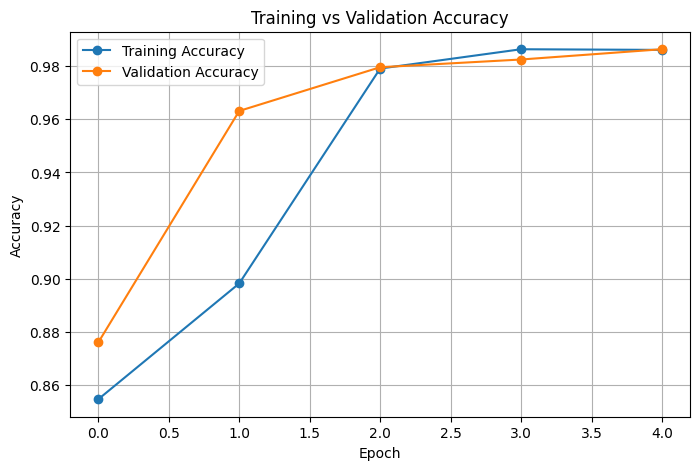

In [ ]:
# Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

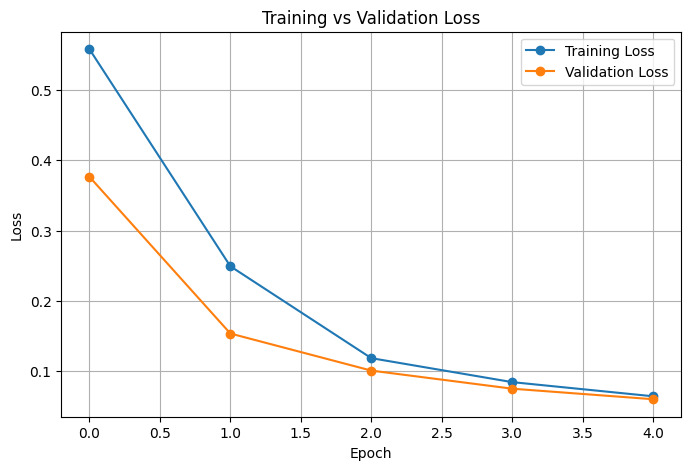

In [ ]:
# Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Final Test Evaluation
test_loss, test_accuracy, y_true, y_pred, y_probability = (
    evaluate_model(
        model,
        test_loader,
        criterion,
        device
    )
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Accuracy: 98.64%


In [ ]:
# Accuracy, Precision, Recall, F1
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

Accuracy : 0.9864
Precision: 0.9385
Recall   : 0.9531
F1-score : 0.9457


In [ ]:
# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[896   8]
 [  6 122]]


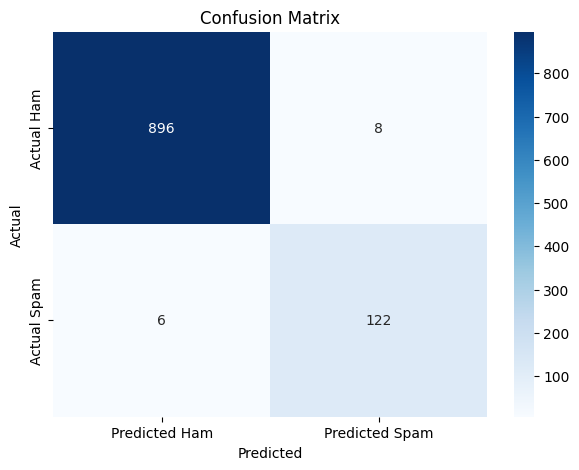

In [ ]:
# Confusion Matrix Graph
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Ham",
        "Predicted Spam"
    ],
    yticklabels=[
        "Actual Ham",
        "Actual Spam"
    ]
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# Classification Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Ham",
            "Spam"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       904
        Spam       0.94      0.95      0.95       128

    accuracy                           0.99      1032
   macro avg       0.97      0.97      0.97      1032
weighted avg       0.99      0.99      0.99      1032



In [ ]:
# Final Evaluation Table
evaluation_table = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation_table

,Metric,Score
0,Accuracy,0.986434
1,Precision,0.938462
2,Recall,0.953125
3,F1-score,0.945736


In [ ]:
error_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Total incorrect predictions:",
    len(error_indices)
)

Total incorrect predictions: 14


In [ ]:
# Error Analysis
error_data = []

for idx in error_indices:

    actual = int(
        y_true[idx]
    )

    predicted = int(
        y_pred[idx]
    )

    probability = float(
        y_probability[idx]
    )

    if predicted == 1:

        confidence = probability

    else:

        confidence = 1 - probability

    actual_label = (
        "Spam"
        if actual == 1
        else "Ham"
    )

    predicted_label = (
        "Spam"
        if predicted == 1
        else "Ham"
    )

    error_data.append({

        "SMS Text": X_test[idx],

        "Actual Label":
            actual_label,

        "Predicted Label":
            predicted_label,

        "Confidence":
            confidence
    })

error_df = pd.DataFrame(
    error_data
)

error_df.head(10)

,SMS Text,Actual Label,Predicted Label,Confidence
0,plz note: if anyone calling from a mobile co. ...,Ham,Spam,0.740927
1,sorry i missed your call let's talk when you h...,Spam,Ham,0.789169
2,wewa is 130. iriver 255. all 128 mb.,Ham,Spam,0.709125
3,babe: u want me dont u baby! im nasty and have...,Spam,Ham,0.994398
4,was playng 9 doors game and gt racing on phone...,Ham,Spam,0.773495
5,v nice! off 2 sheffield tom 2 air my opinions ...,Ham,Spam,0.698276
6,thesmszone.com lets you send free anonymous an...,Spam,Ham,0.720983
7,am only searching for good dual sim mobile pa.,Ham,Spam,0.763177
8,hello which the site to download songs its urg...,Ham,Spam,0.750764
9,dating:i have had two of these. only started a...,Spam,Ham,0.982001


In [ ]:
# Possible Reason for Error
def find_error_reason(text):

    text_lower = text.lower()

    if (
        "http" in text_lower
        or "www" in text_lower
        or ".com" in text_lower
    ):
        return "URL"

    if re.search(
        r"\d+",
        text_lower
    ):
        return "Numbers"

    if len(
        text.split()
    ) <= 4:
        return "Short message"

    if len(
        text.split()
    ) >= 30:
        return "Long message"

    promotional_words = [
        "free",
        "win",
        "winner",
        "prize",
        "offer",
        "claim",
        "cash",
        "urgent",
        "bonus"
    ]

    if any(
        word in text_lower
        for word in promotional_words
    ):
        return "Promotional language"

    return "Informal or ambiguous wording"

In [ ]:
# Add Error Reason
error_df[
    "Possible Reason"
] = error_df[
    "SMS Text"
].apply(
    find_error_reason
)

error_df.head(10)

,SMS Text,Actual Label,Predicted Label,Confidence,Possible Reason
0,plz note: if anyone calling from a mobile co. ...,Ham,Spam,0.740927,Long message
1,sorry i missed your call let's talk when you h...,Spam,Ham,0.789169,Numbers
2,wewa is 130. iriver 255. all 128 mb.,Ham,Spam,0.709125,Numbers
3,babe: u want me dont u baby! im nasty and have...,Spam,Ham,0.994398,Numbers
4,was playng 9 doors game and gt racing on phone...,Ham,Spam,0.773495,Numbers
5,v nice! off 2 sheffield tom 2 air my opinions ...,Ham,Spam,0.698276,Numbers
6,thesmszone.com lets you send free anonymous an...,Spam,Ham,0.720983,URL
7,am only searching for good dual sim mobile pa.,Ham,Spam,0.763177,Informal or ambiguous wording
8,hello which the site to download songs its urg...,Ham,Spam,0.750764,Promotional language
9,dating:i have had two of these. only started a...,Spam,Ham,0.982001,Informal or ambiguous wording


In [ ]:
# Prediction Function
def predict_sms(text):

    model.eval()

    cleaned_text = clean_text(
        text
    )

    encoding = tokenizer(
        cleaned_text,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    input_ids = encoding[
        "input_ids"
    ].to(device)

    attention_mask = encoding[
        "attention_mask"
    ].to(device)

    with torch.no_grad():

        output = model(
            input_ids,
            attention_mask
        )

        probability = torch.sigmoid(
            output
        ).item()

    if probability >= 0.5:

        prediction = "SPAM"

        confidence = probability

    else:

        prediction = "HAM"

        confidence = 1 - probability

    return (
        prediction,
        confidence
    )

In [ ]:
# Test One SMS
sms = (
    "Congratulations! You have won "
    "a free iPhone. Click here now!"
)

prediction, confidence = predict_sms(
    sms
)

print(
    "SMS:",
    sms
)

print(
    "Prediction:",
    prediction
)

print(
    f"Confidence: "
    f"{confidence * 100:.2f}%"
)

SMS: Congratulations! You have won a free iPhone. Click here now!
Prediction: SPAM
Confidence: 73.08%


The proposed hybrid model combines DistilBERT, LSTM, and Bidirectional GRU networks for SMS spam classification. DistilBERT first generates contextual representations of the SMS text. These representations are then processed by an LSTM to capture sequential dependencies, followed by a Bidirectional GRU to capture information from both forward and backward directions. The resulting representation is passed through global average pooling, dropout, a dense layer, and a sigmoid output layer to classify each SMS as Ham or Spam.